# Employee engagement and performance analytics

**A Great Place To Work style survey: 5,000 responses, 68 questions, 8 culture topics.**

I ran this to answer one practical question: *if a company can only fix one or
two things about how it treats people, which ones should it pick?*

The short version of what I found:

| | |
|---|---|
| **Where we stand** | Only about a third of employees rate most topics favourably. 21% are at risk. |
| **What to fix first** | **Leadership and fairness** — they move satisfaction most and score among the worst. |
| **Where** | Chennai, 0.27 points below the company average on wellbeing. |
| **What it costs** | 73% of people under weak leadership are at risk, against 4% under strong leadership. |
| **Does it reach the money** | Units with better culture are more profitable (r = 0.45), but on 24 units that is a signal to test, not a proven link. |

---

> **A note on the data before anything else.** I lost the original survey file, so
> the data here is **generated**, not collected. I built it from a latent-factor
> model (`src/generate_synthetic_data.py`) where hidden culture factors cause the
> answers, so that the reliability and factor structure had to be discovered by
> the analysis rather than assumed by me. **Every method and every number below is
> real; the respondents are not.** Nothing here is a finding about actual people.

## 1. The question I set out to answer

Engagement surveys produce a wall of numbers and almost no decisions. I wanted
to get from 68 questions to something a manager could act on, which meant
answering four things in order:

1. Do these 68 questions actually measure 8 separate things, or am I just
   asserting that they do?
2. Which topics genuinely move employee satisfaction, once they are all
   considered together?
3. Where in the company is the problem — which sites, which units?
4. Does any of it show up in the business numbers?

The hard part is question 2. The eight culture topics correlate with each other
at 0.60 to 0.76, so looking at them one at a time tells you nothing — everything
looks important. Only a model that holds the others constant can separate them.

In [1]:
import contextlib
import io
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd() / "src"))
import config
import step_06_figures as figures
import plot_style as style

style.apply_house_style()
pd.set_option("display.width", 140)


def draw(plot_function, *arguments, width=940):
    """Run one of the project chart functions and show the result here."""
    with contextlib.redirect_stdout(io.StringIO()):
        filename = plot_function(*arguments)
    display(Image(str(config.FIGURES_DIR / filename), width=width))


scores = pd.read_parquet(config.CONSTRUCT_SCORE_FILE)
unit_data = pd.read_csv(config.RESULTS_DIR / "05_unit_level_data.csv")
print(f"{len(scores):,} employees scored on {len(config.CONSTRUCTS)} culture topics")

4,850 employees scored on 8 culture topics


## 2. The data

68 questions on a 1-5 scale, grouped into 8 culture topics of 8 questions each,
plus a separate 4-question satisfaction scale that I use as the outcome. Keeping
the outcome separate matters — if satisfaction were built from the same
questions as the predictors, the model would partly be predicting a variable
from itself.

Six of the 68 questions are deliberately worded negatively ("management hides
bad news from staff"). That is there to catch people who tick 4 all the way down
the page without reading.

In [2]:
raw = pd.read_csv(config.RAW_SURVEY_FILE)
print(f"raw file: {len(raw):,} rows x {raw.shape[1]} columns")
print(f"culture questions: {len(config.CONSTRUCTS) * config.ITEMS_PER_CONSTRUCT}")
print(f"satisfaction questions: {len(config.SATISFACTION_ITEMS)}")
print(f"reverse-worded: {', '.join(config.REVERSE_ITEMS)}")
print()
print("business units:", scores["business_unit"].nunique())
print("sites:", ", ".join(sorted(scores["location"].unique())))

raw file: 5,012 rows x 74 columns
culture questions: 64
satisfaction questions: 4
reverse-worded: cred_04, resp_06, fair_03, camr_08, lead_07, well_05

business units: 24
sites: Aarhus, Chennai, Hamburg, Pune, Remote, Rostock


## 3. Cleaning

Four things were wrong with the raw export, and I logged every change rather
than quietly fixing them.

**Straight-liners had to be found before reverse-coding, not after.** Someone
who ticks 4 for all 68 questions has zero variance in the raw file, so they are
easy to spot. But if I flip the six reverse-worded questions first, their 4s
become 2s, they suddenly look like they varied their answers, and they slip
through the filter. I got this wrong the first time round. 150 people (3%) were
removed this way.

**Missing answers: I did not use listwise deletion.** Only 2.7% of individual
answers are missing, but they are spread thinly across 68 questions, so almost
every person has *something* missing. Dropping every row with any gap would have
left **792 of 4,850 people — 16%**. Instead each topic score is the average of
the questions that person actually answered, provided they answered at least
half of that topic.

In [3]:
cleaning_log = pd.read_csv(config.RESULTS_DIR / "01_cleaning_log.csv")
display(cleaning_log[["step", "affected", "unit", "pct_affected", "rows_remaining"]])

kept = len(scores) / len(raw) * 100
print(f"kept {len(scores):,} of {len(raw):,} rows ({kept:.1f}%)")

,step,affected,unit,pct_affected,rows_remaining
0,Drop duplicate respondent_id rows,12,rows,0.24,5000
1,Standardise demographic category text,60,cells,1.20,5000
2,Set out-of-scale answers to missing,69,values,0.02,5000
3,Drop straight-lining respondents,150,rows,3.00,4850
4,Reverse-code negatively worded items,28363,values,8.60,4850
5,Drop respondents missing >30% of items,0,rows,0.00,4850
6,Missing-data policy: available-item scoring (N...,8796,values,2.67,4850


kept 4,850 of 5,012 rows (96.8%)


## 4. Turning 68 questions into 8 scores

Two different questions get asked here and they are easy to confuse.

**Reliability** (Cronbach's alpha) asks: do these 8 questions move together?
**Validity** (factor analysis) asks: do they move together *for the reason I
think*, or is it all one big blob?

A set of questions can pass the first test and fail the second. That is exactly
what happened, so I report both instead of only the flattering one.

In [4]:
reliability = pd.read_csv(config.RESULTS_DIR / "02_reliability_table.csv")
display(reliability[["construct", "n_items_retained", "dropped_items",
                     "alpha_before", "alpha_after"]])

,construct,n_items_retained,dropped_items,alpha_before,alpha_after
0,credibility,8,none,0.867,0.867
1,respect,8,none,0.850,0.850
2,fairness,8,none,0.882,0.882
3,pride,8,none,0.893,0.893
4,camaraderie,8,none,0.880,0.880
5,leadership,8,none,0.878,0.878
6,development,7,devl_04,0.869,0.888
7,wellbeing,8,none,0.879,0.879
8,satisfaction (outcome),4,none,0.872,0.872


**Reliability: fine.** Alpha runs from 0.850 (respect) to 0.893 (pride), all
comfortably above the 0.80 convention. One question was dropped — `devl_04`
("I am given challenging work that stretches me") correlated only 0.29 with the
rest of its topic, and removing it lifted development from 0.869 to 0.888.

I only drop a question if it fails **two** tests: weak correlation with its own
topic *and* alpha improves without it. Requiring both matters, because four of
the six reverse-worded questions would have raised alpha if deleted. A
one-condition rule would have quietly stripped out every reverse question and
reported a higher alpha as a success — while removing the only protection the
survey has against people ticking straight down the page.

**Validity: not fine, and this is the honest bit.**

In [5]:
structure = pd.read_csv(config.RESULTS_DIR / "02_structure_check.csv")
display(structure[["construct", "modal_factor", "n_items_on_modal_factor", "share_agreeing"]])

eigenvalues = pd.read_csv(config.RESULTS_DIR / "02_eigenvalues.csv")
print(f"first eigenvalue:  {eigenvalues['eigenvalue'].iloc[0]:.2f}")
print(f"second eigenvalue: {eigenvalues['eigenvalue'].iloc[1]:.2f}")
print()
correlations = scores[config.CONSTRUCTS].corr()
print(f"credibility vs leadership: r = {correlations.loc['credibility', 'leadership']:.2f}")
print(f"distinct factors found: {structure['modal_factor'].nunique()} (theory says 8)")

,construct,modal_factor,n_items_on_modal_factor,share_agreeing
0,credibility,F1,7,0.88
1,respect,F7,8,1.00
2,fairness,F6,8,1.00
3,pride,F2,8,1.00
4,camaraderie,F5,8,1.00
5,leadership,F1,7,0.88
6,development,F3,7,1.00
7,wellbeing,F4,8,1.00


first eigenvalue:  23.85
second eigenvalue: 2.19

credibility vs leadership: r = 0.76
distinct factors found: 7 (theory says 8)


Three things came out of the factor analysis, none of them flattering:

- **The 8 topics collapse onto 7 factors.** Credibility and leadership both load
  on the same factor and correlate at 0.76. Statistically they are one thing, not
  two. They are both really asking "do I believe the people in charge?"
- **The first eigenvalue is 23.85 against a second of 2.19.** One enormous
  general factor sits underneath everything — a halo effect. People who like one
  thing about their employer tend to like everything about it.
- **An eighth factor turned out to be made only of the six reverse-worded
  questions.** That is a factor about grammar, not about the workplace. Some
  people do not fully register the switch from "management is honest" to
  "management hides bad news", so those six questions end up sharing something
  for a purely linguistic reason.

I am reporting this rather than smoothing it over, because it changes how much
weight the driver ranking below can carry.

**Scores are simple averages, not factor scores.** An average stays on the
original 1-5 scale, so "3.8 on fairness" means something to a manager and can be
compared with next year. Factor scores use weights calculated from this
particular sample, so they change every time the survey runs and year-on-year
tracking stops making sense.

---

# Part 2: what the business should do about it

The rest of the notebook is the part a management team would actually read.

## 5. Where we stand today

Two definitions, both standard in engagement survey work:

- **Favourable** = the share of people scoring 4 or 5 out of 5.
- **At risk** = overall satisfaction below 3.0. The satisfaction scale includes
  "I rarely think about leaving", so a low score is the closest thing this survey
  has to a flight-risk signal. It is a proxy, not observed turnover.

pride          41.0
development    41.0
fairness       32.4
camaraderie    32.4
leadership     32.2
wellbeing      32.1
credibility    31.6
respect        31.2

satisfaction favourable: 44.9%
at risk: 1,034 employees (21.3%)


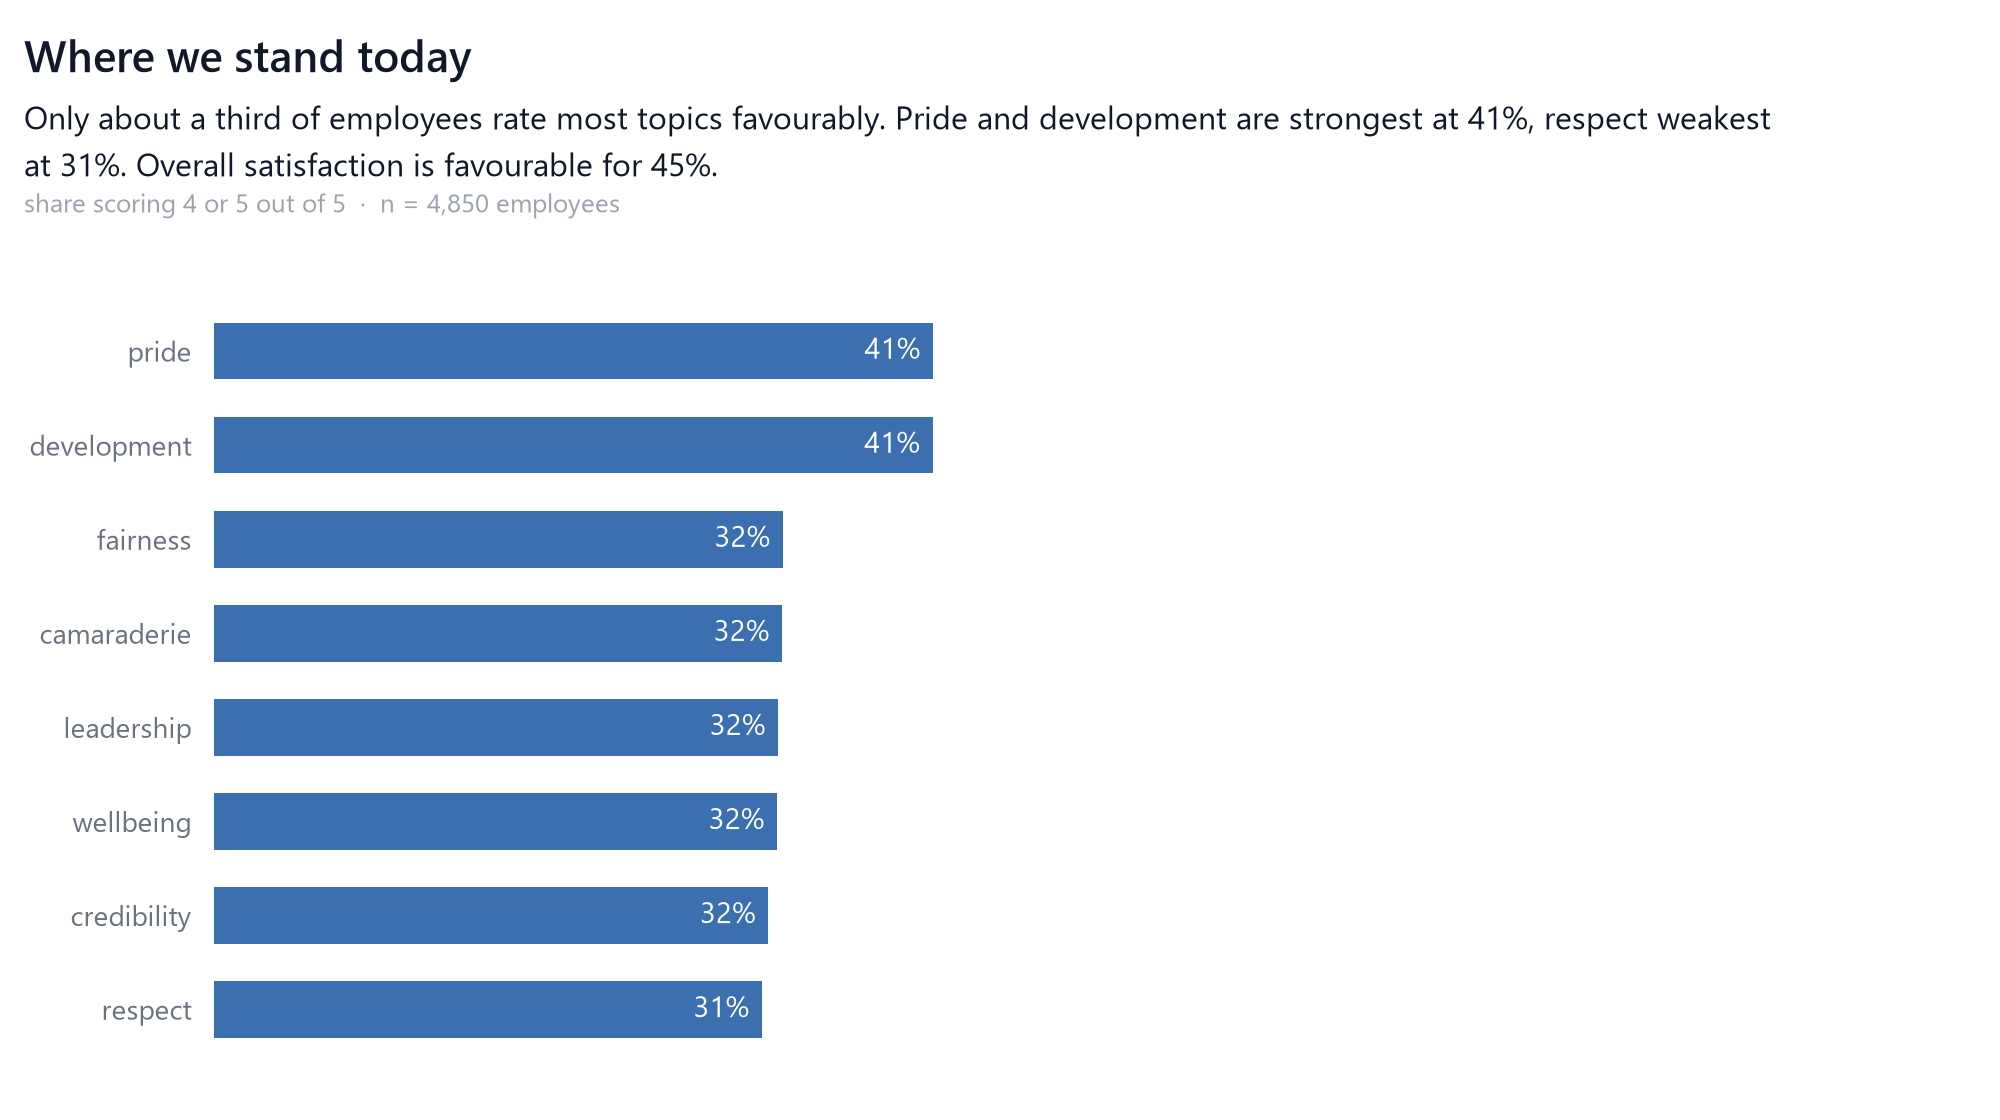

In [6]:
favourable = figures.favourable_rates(scores).sort_values(ascending=False)
at_risk_rate = (scores["satisfaction"] < figures.AT_RISK_THRESHOLD).mean() * 100
at_risk_count = int((scores["satisfaction"] < figures.AT_RISK_THRESHOLD).sum())

print(favourable.round(1).to_string())
print()
print(f"satisfaction favourable: "
      f"{(scores['satisfaction'] >= 4).mean() * 100:.1f}%")
print(f"at risk: {at_risk_count:,} employees ({at_risk_rate:.1f}%)")

draw(figures.plot_where_we_stand, scores)

**What this says.** Only about a third of employees rate most topics
favourably. Respect is weakest at 31%, pride and development strongest at 41%.
Overall satisfaction is favourable for 45%, and **21% of the workforce — 1,034
people — are at risk**.

The topics are also bunched: six of the eight sit between 31% and 32%. So the
current scores on their own do not tell me what to prioritise. For that I need
to know which topics actually *move* satisfaction.

## 6. What to fix first

This is the modelling question. I regressed satisfaction on all eight topics at
once, plus department, tenure, location and role level as controls.

Doing it in one model is the whole point. Looked at one at a time, every topic
correlates with satisfaction at about 0.53-0.59 — they all look equally
important. Only holding the others constant separates them.

In [7]:
regression = pd.read_csv(config.RESULTS_DIR / "04_regression_table.csv")
diagnostics = pd.read_csv(config.RESULTS_DIR / "04_model_diagnostics.csv").iloc[0]
vif = pd.read_csv(config.RESULTS_DIR / "04_vif_table.csv")
ranking = pd.read_csv(config.RESULTS_DIR / "04_driver_ranking.csv")

print(f"R-squared:          {diagnostics['r_squared']:.3f}")
print(f"adjusted R-squared: {diagnostics['adj_r_squared']:.3f}")
print(f"observations:       {int(diagnostics['n_obs']):,}")
print(f"highest VIF among the topics: "
      f"{vif.loc[vif['is_construct'], 'vif'].max():.2f}  (5 is the usual warning line)")
print(f"Breusch-Pagan p = {diagnostics['breusch_pagan_p']:.2e} -> using HC3 robust standard errors")
print()
display(ranking[["rank_by_std_beta", "construct", "std_beta",
                 "zero_order_r", "delta_r_squared_if_removed"]])

R-squared:          0.474
adjusted R-squared: 0.471
observations:       4,846
highest VIF among the topics: 2.98  (5 is the usual warning line)
Breusch-Pagan p = 2.22e-15 -> using HC3 robust standard errors



,rank_by_std_beta,construct,std_beta,zero_order_r,delta_r_squared_if_removed
0,1,leadership,0.1830,0.591,0.01124
1,2,fairness,0.1724,0.585,0.01203
2,3,pride,0.1453,0.572,0.00862
3,4,credibility,0.0929,0.572,0.00295
4,5,respect,0.0872,0.541,0.00330
5,6,development,0.0586,0.535,0.00142
6,7,wellbeing,0.0478,0.531,0.00092
7,8,camaraderie,0.0385,0.534,0.00061


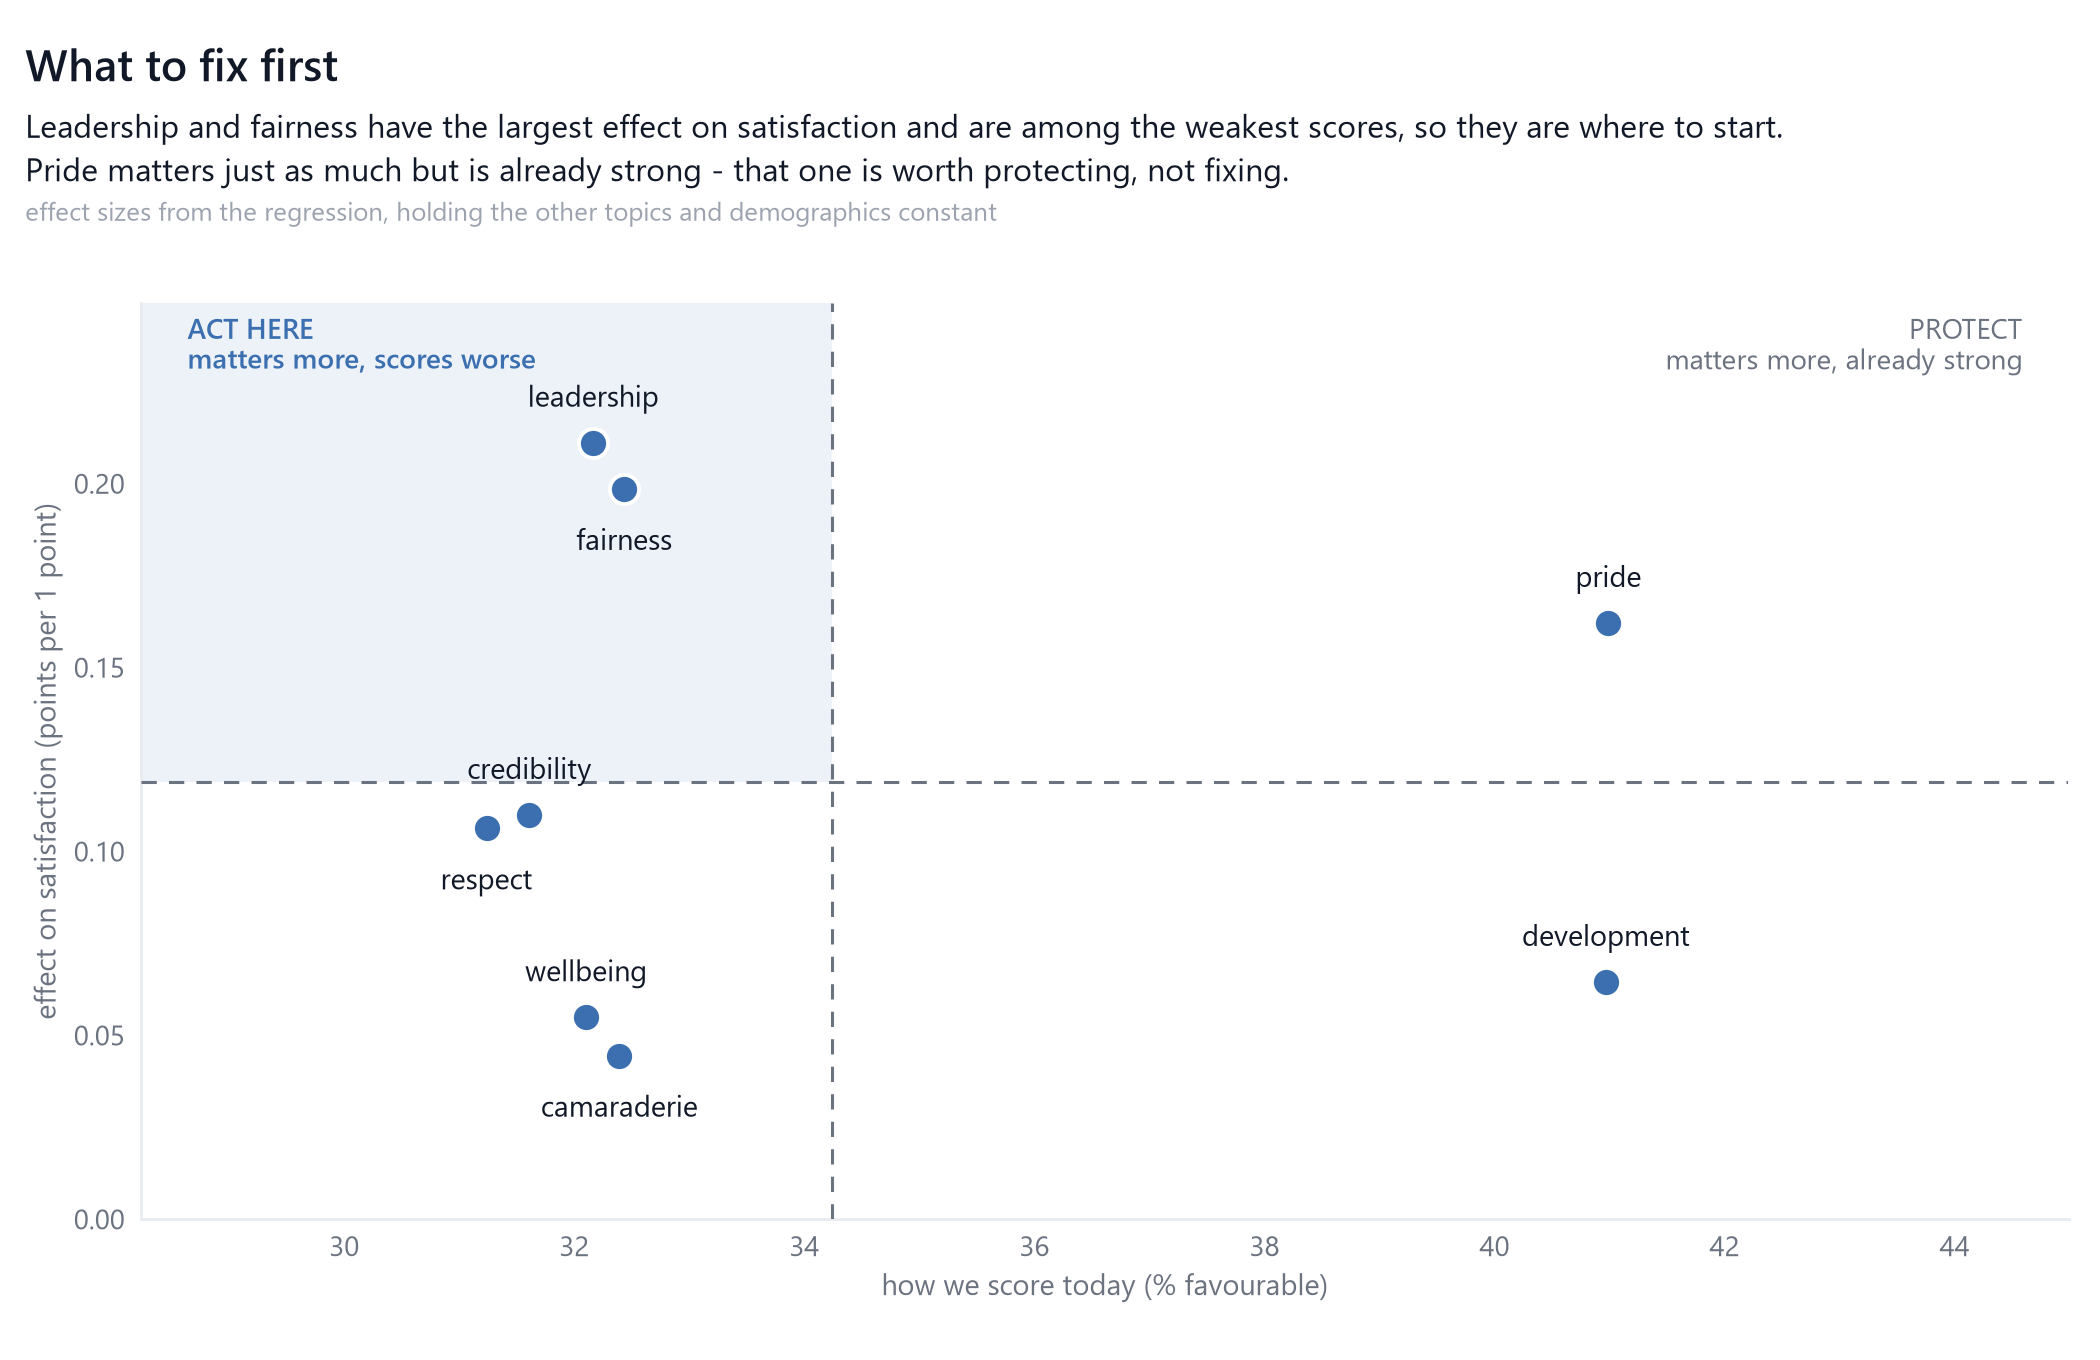

In [8]:
draw(figures.plot_priority_matrix, scores)

**What this says.** Leadership and fairness have the largest effect on
satisfaction *and* score among the worst — that is where to start. Pride matters
just as much but is already the strongest topic, so it is worth protecting
rather than investing in.

**The model explains 47% of the differences between individuals** (R² = 0.474,
adjusted 0.471 — the gap is tiny, so the model is not being flattered by its 26
terms). For cross-sectional survey data that is normal; it is not a good or bad
number without that context.

**Three caveats I would not skip past:**

- **Multicollinearity.** The highest VIF is 2.98, below the usual warning line of
  5, so the model is estimable. But that does *not* mean the topics are distinct
  — credibility and leadership still correlate at 0.76. The consequence is that
  the individual coefficients are reliable enough to report while the *ranking*
  between them is fragile. The `delta_r_squared_if_removed` column shows why:
  the best topic uniquely explains only **1.2%** of the variance, and the other
  46% is shared between all eight. So my claim is that leadership, fairness and
  pride form a top tier clearly separated from wellbeing and camaraderie — not
  that leadership is precisely first.
- **Heteroscedasticity.** The residual spread varies with the fitted values
  (Breusch-Pagan p = 2.2e-15), which is normal for a bounded 1-5 outcome. All
  inference uses HC3 robust standard errors, which change the uncertainty around
  the coefficients but not the coefficients themselves.
- **"Driver" means association.** The data is one survey at one point in time.
  "Satisfied people rate their managers more generously" fits it just as well as
  "good managers make people satisfied", and nothing here separates the two.

## 7. Where the problem sits

Company averages hide everything. I plotted each site as its *gap* from the
company average rather than its raw score — a grid of numbers all around 3.5
tells you nothing, a grid of gaps tells you where to go.

,credibility,respect,fairness,pride,camaraderie,leadership,development,wellbeing
location,,,,,,,,
Chennai,-0.00,0.01,0.01,0.01,0.02,-0.15,0.00,-0.27
Remote,-0.06,-0.06,-0.04,-0.06,-0.04,-0.10,-0.07,-0.07
Rostock,0.01,0.04,-0.00,0.01,0.01,-0.03,0.02,-0.04
Hamburg,0.00,-0.02,-0.01,-0.01,0.00,0.04,-0.03,0.04
Pune,0.01,0.03,0.02,0.03,0.02,0.10,0.05,0.14
Aarhus,0.04,0.01,0.02,0.03,-0.03,0.11,0.01,0.18


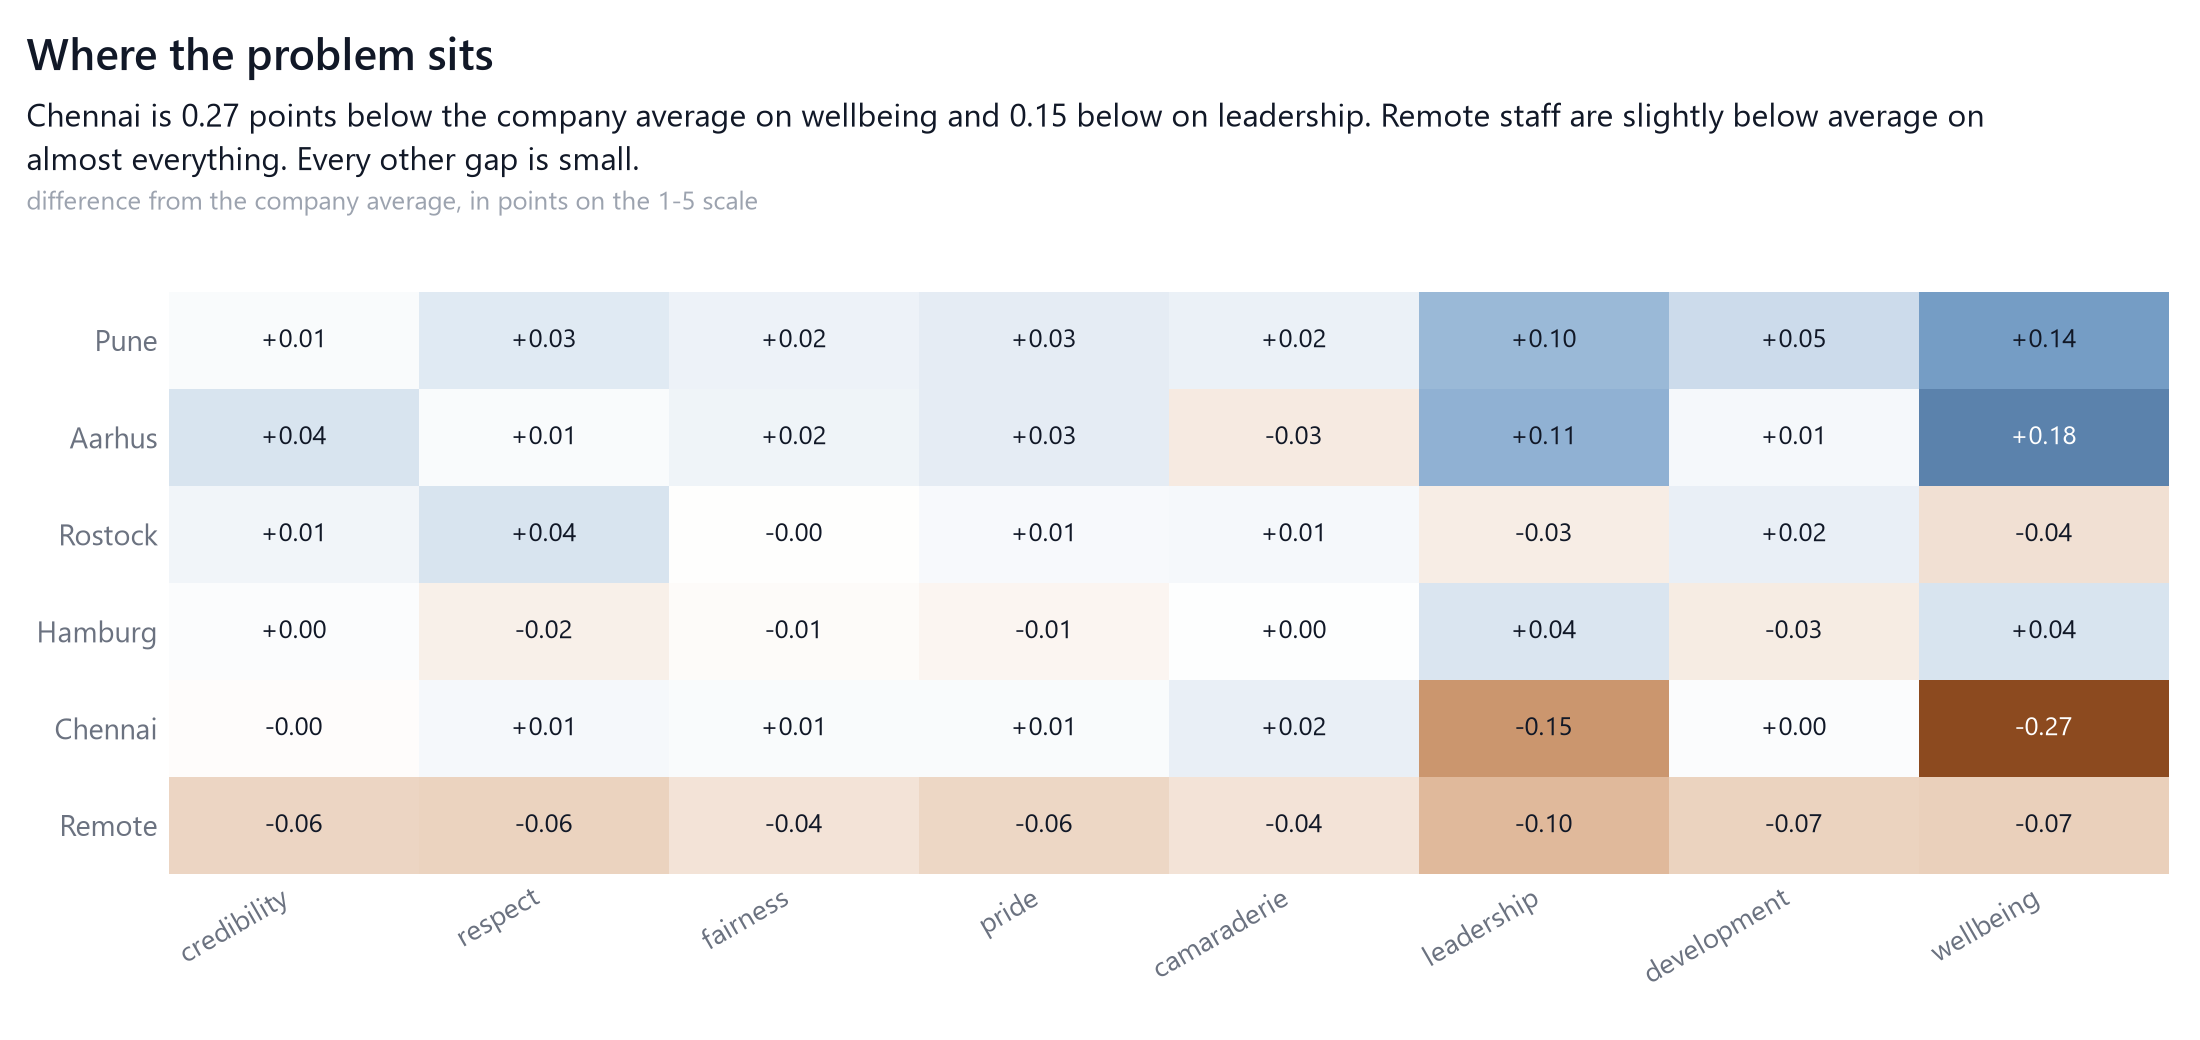

In [9]:
site_means = scores.groupby("location")[config.CONSTRUCTS].mean()
gaps = site_means - scores[config.CONSTRUCTS].mean()
display(gaps.round(2).sort_values("wellbeing"))

draw(figures.plot_site_gaps, scores)

**What this says.** Chennai is the one site with a real problem: **0.27
points below the company average on wellbeing** and 0.15 below on leadership.
Remote workers sit slightly below average on almost everything, which is worth
noting but is a smaller effect. Every other gap is under a tenth of a point.

Worth being honest about the size of this. In the formal ANOVA, wellbeing by
location is the **largest effect anywhere in the analysis at eta squared =
0.032** — location explains 3.2% of the variation in wellbeing. That is real and
worth one targeted intervention. It is not the dramatic finding a very small
p-value might make it sound like.

I ran 24 of those tests (8 topics x 3 groupings) and corrected for multiple
comparisons with Benjamini-Hochberg. Only 4 came out significant, and those same
4 are the only ones reaching even a small effect size — so here the two measures
agree.

## 8. What weak leadership costs

This is the clearest business consequence in the survey, and the single chart I
would put in front of an executive.

,% at risk,employees
band,,
2.0 or below,73.2,250
2.0-2.5,50.6,466
2.5-3.0,34.0,745
3.0-3.5,21.1,1015
3.5-4.0,9.1,1069
4.0-5.0,3.9,1305


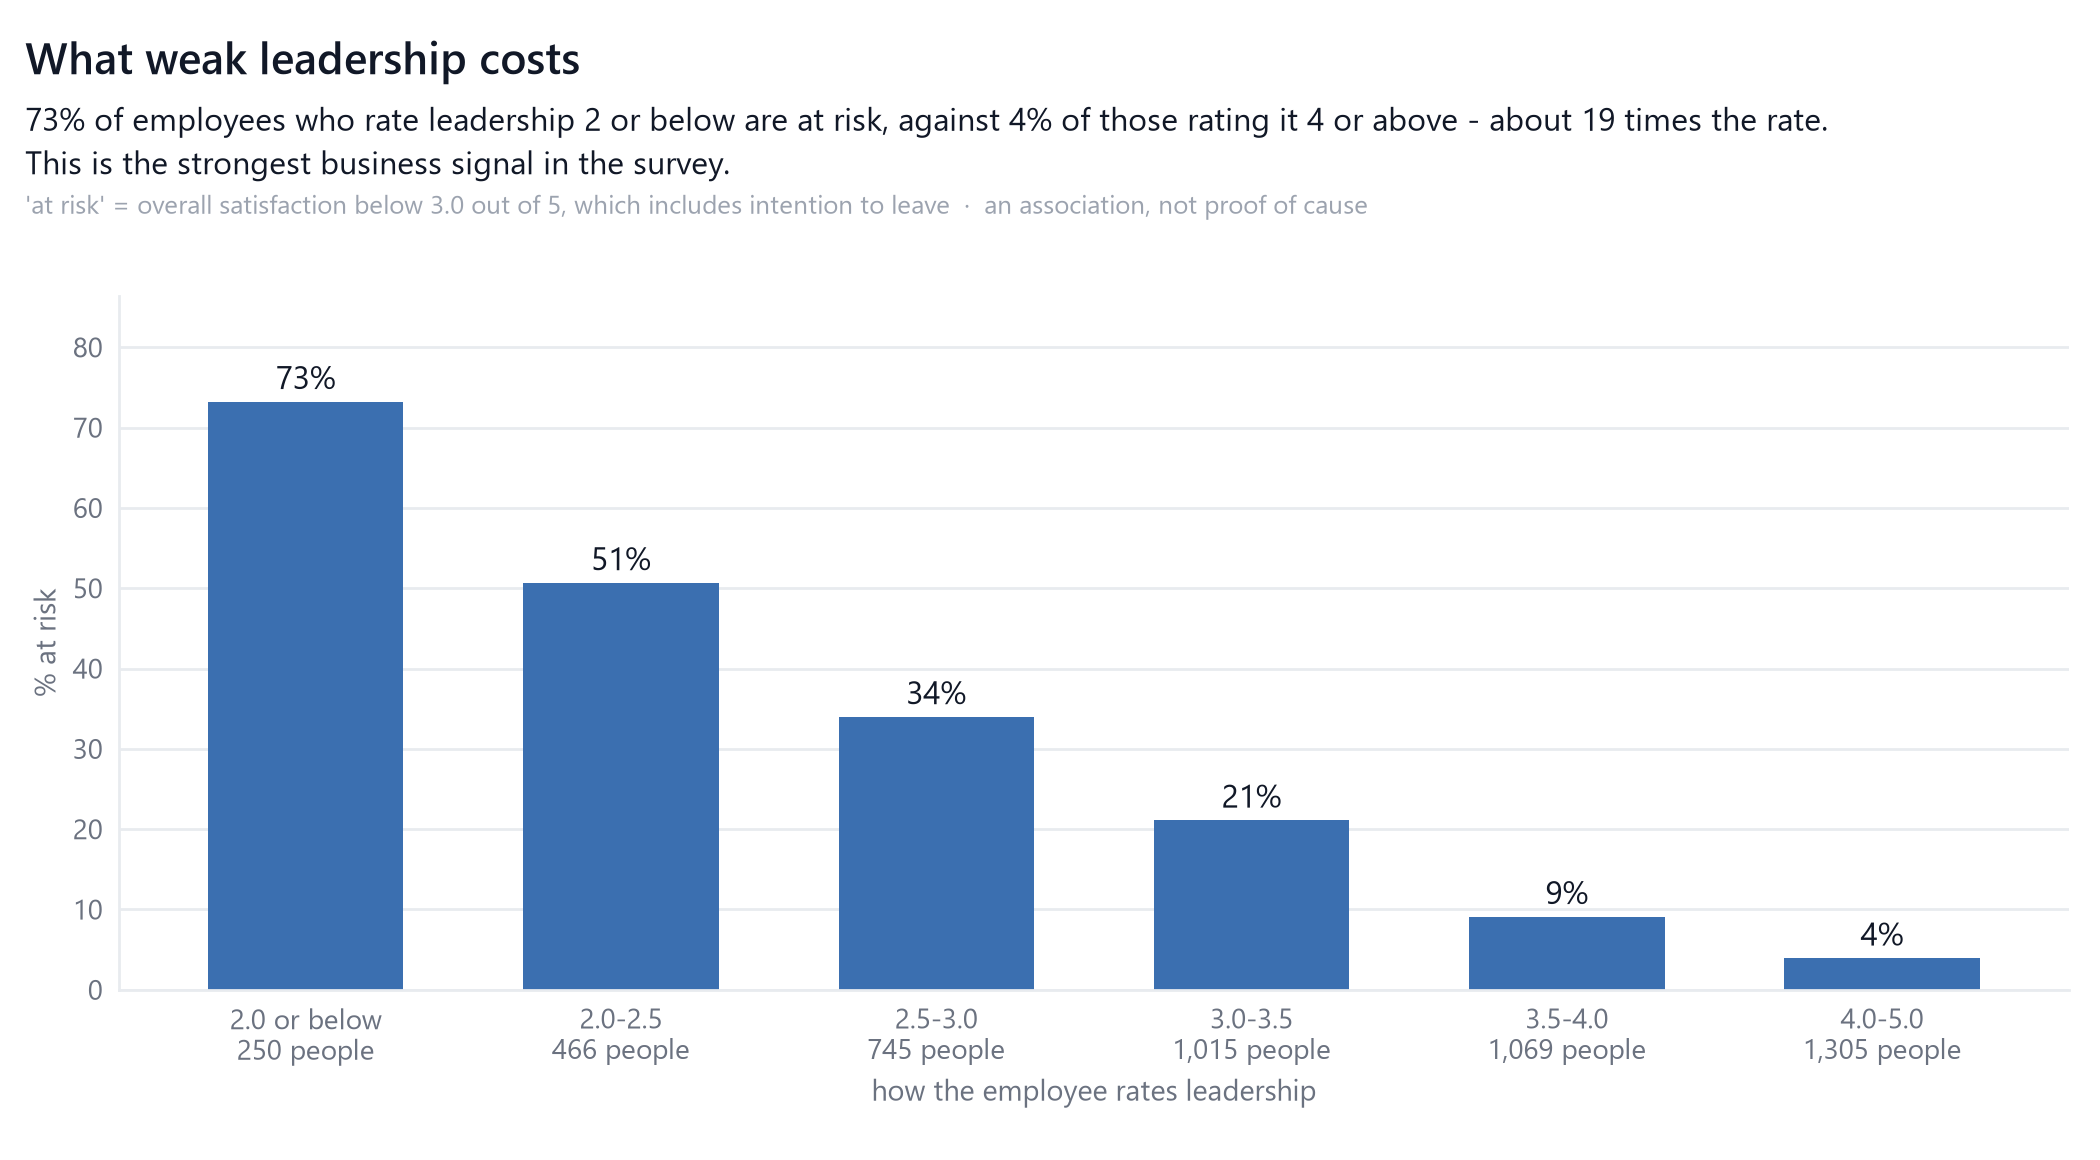

In [10]:
at_risk = scores["satisfaction"] < figures.AT_RISK_THRESHOLD
bands = pd.cut(scores["leadership"], [0, 2, 2.5, 3, 3.5, 4, 5],
               labels=["2.0 or below", "2.0-2.5", "2.5-3.0",
                       "3.0-3.5", "3.5-4.0", "4.0-5.0"])
gradient = pd.DataFrame({"at_risk": at_risk, "band": bands}).dropna()
gradient = gradient.groupby("band", observed=True)["at_risk"].agg(["mean", "size"])
gradient["mean"] = (gradient["mean"] * 100).round(1)
display(gradient.rename(columns={"mean": "% at risk", "size": "employees"}))

draw(figures.plot_risk_gradient, scores)

**What this says.** **73% of employees who rate their leadership 2 or below
are at risk, against 4% of those rating it 4 or above — roughly nineteen times
the rate.** The gradient is clean and steep the whole way down: 73%, 51%, 34%,
21%, 9%, 4%.

**What I would not claim from it.** This is a correlation between two answers on
the same questionnaire. An unhappy employee may well mark their manager down
because they are unhappy, rather than being unhappy because of the manager. The
honest reading is that weak leadership ratings reliably identify where the
at-risk people are — which is useful for targeting even if the causal direction
is unresolved.

## 9. Which units need attention

A percentage on its own does not tell you where to spend the effort. A 37% rate
in a small unit is a different decision from a 30% rate in a large one, so the
number of people behind each percentage is on the chart too.

,at_risk_pct,headcount,people_at_risk
business_unit,,,
BU03,37.4,219,82
BU02,34.8,92,32
BU11,34.1,232,79
BU06,31.8,157,50
BU20,31.5,314,99
BU23,30.5,282,86
BU13,30.0,160,48
BU18,27.3,165,45


the five worst units hold 342 at-risk employees (33% of all at-risk staff)


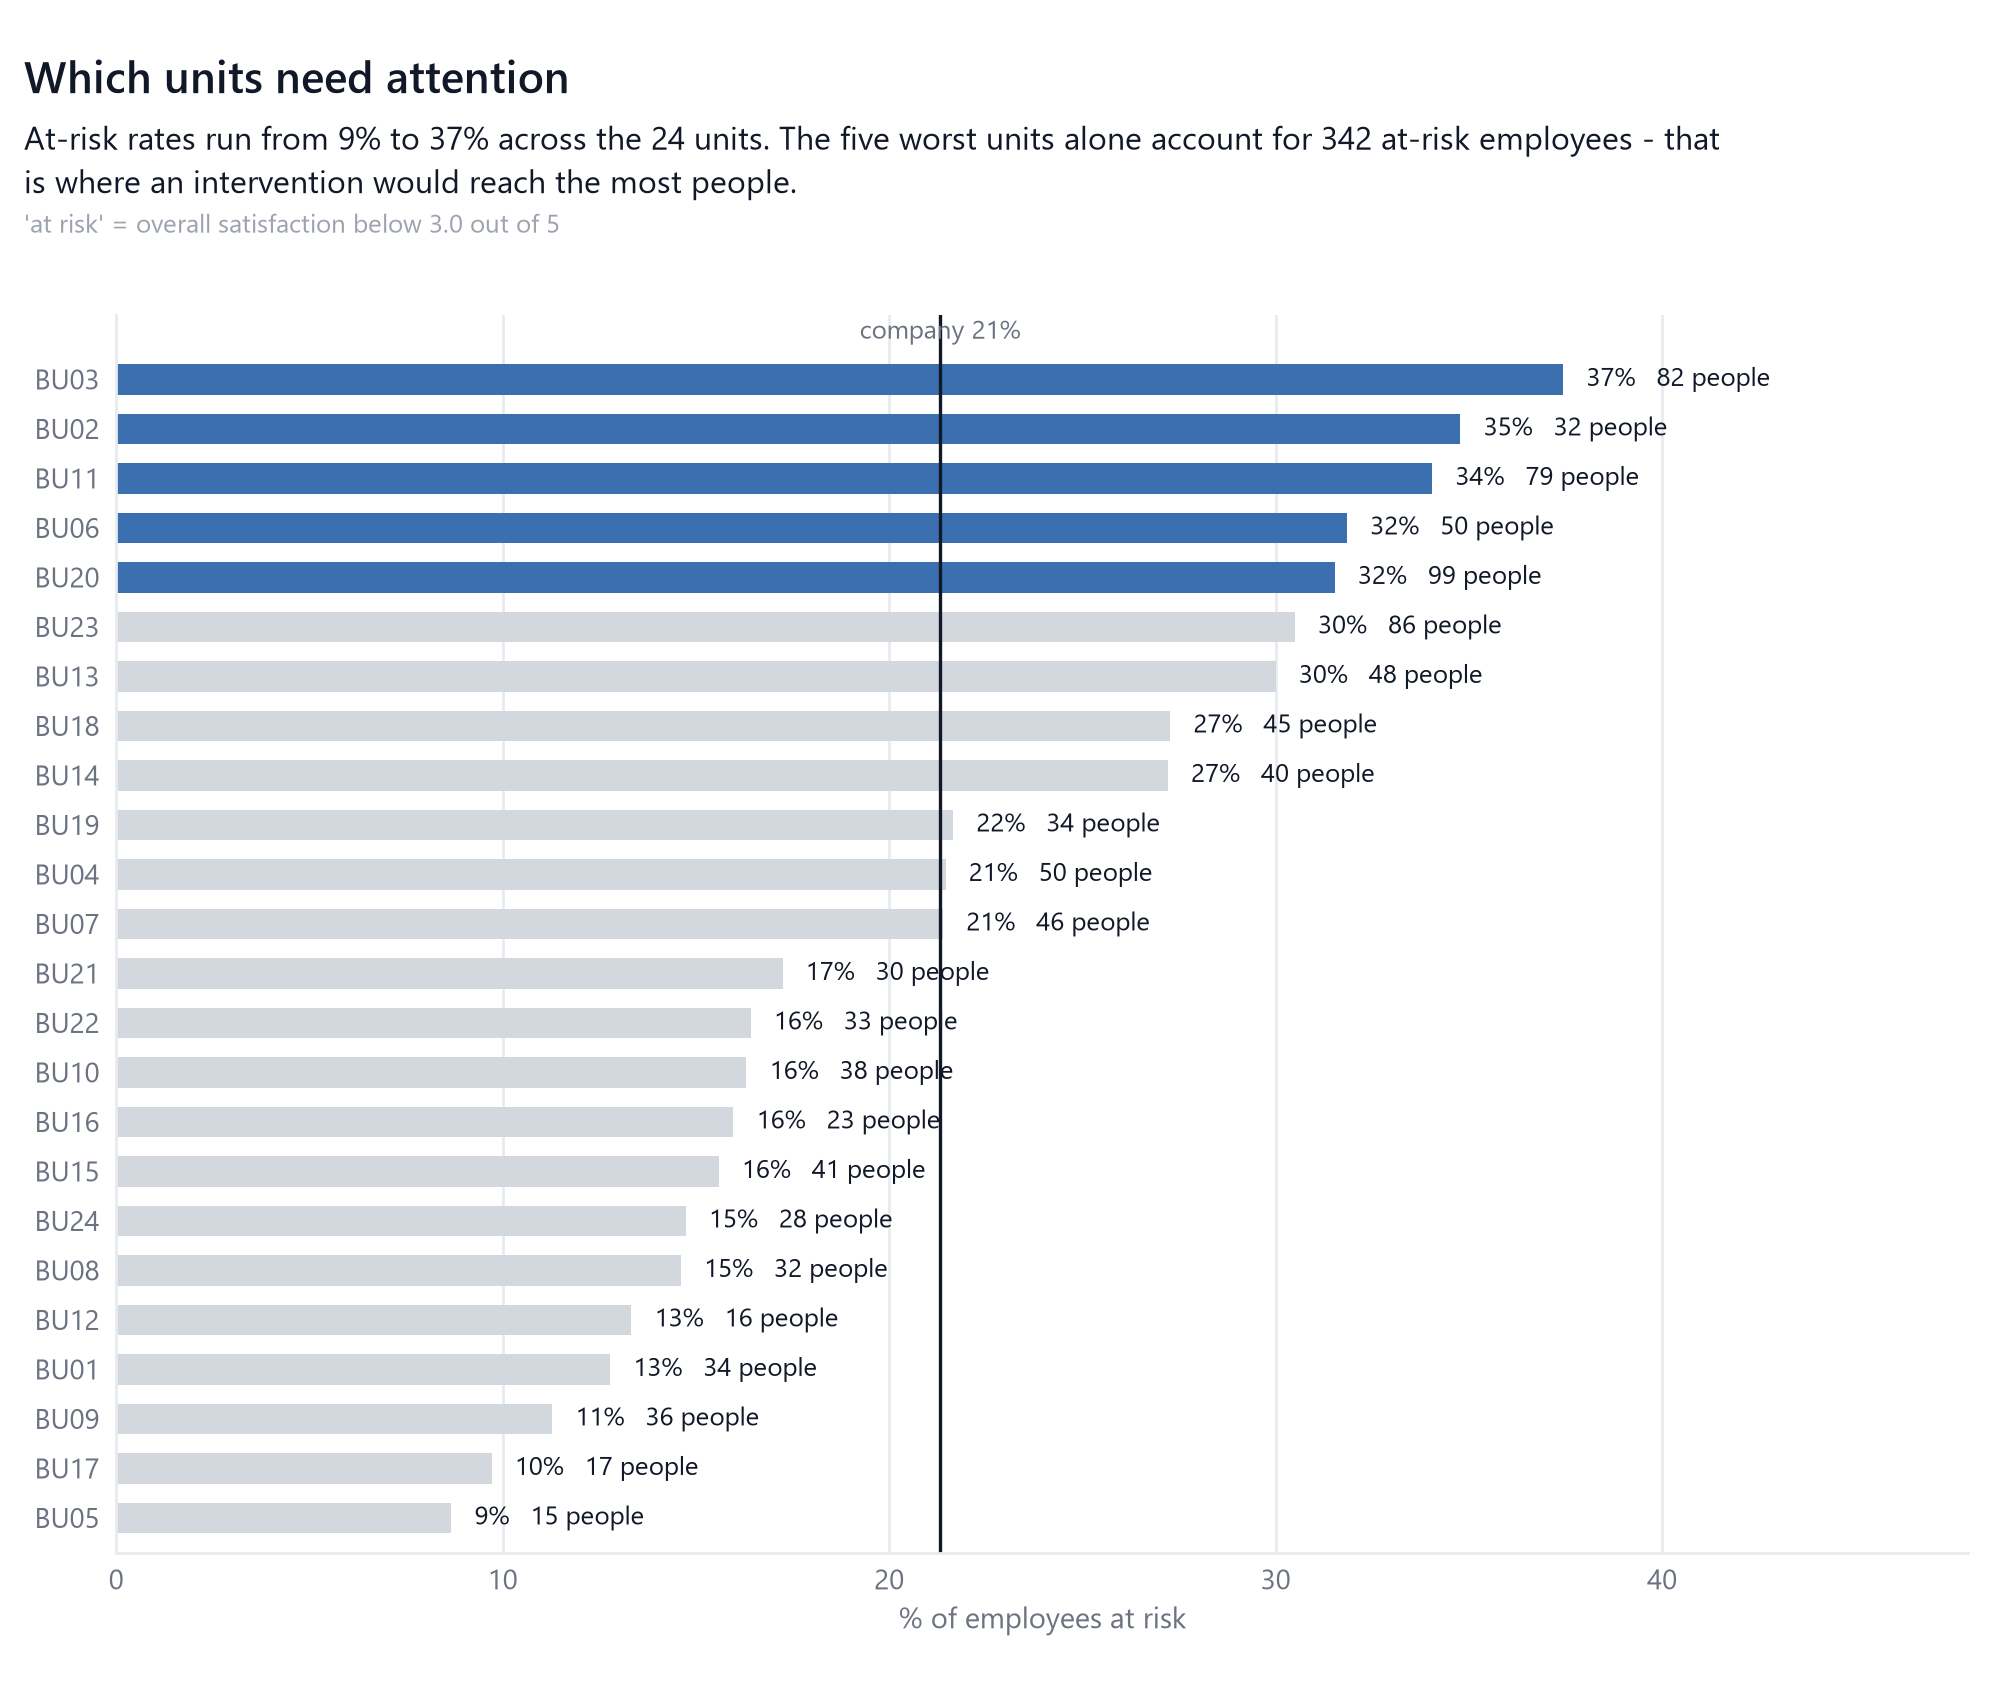

In [11]:
units = scores.assign(at_risk=at_risk).groupby("business_unit").agg(
    at_risk_pct=("at_risk", "mean"), headcount=("at_risk", "size"),
    people_at_risk=("at_risk", "sum"))
units["at_risk_pct"] = (units["at_risk_pct"] * 100).round(1)
units = units.sort_values("at_risk_pct", ascending=False)
display(units.head(8))

worst_five = units.head(5)["people_at_risk"].sum()
print(f"the five worst units hold {worst_five} at-risk employees "
      f"({worst_five / at_risk_count * 100:.0f}% of all at-risk staff)")

draw(figures.plot_units_at_risk, scores)

**What this says.** At-risk rates run from 9% to 37% across the 24 units,
against a company figure of 21%. **The five worst units account for 342 at-risk
employees — a third of everyone at risk in the company.** That is where an
intervention reaches the most people per unit of effort.

One statistical note that stops this being over-read: which unit someone works
in explains only **11% of their individual score** (ICC(1) = 0.11). Units differ,
but most of the variation in how people feel is *within* units, not between
them. So unit-level action is worth taking, and it will not fix everything.

## 10. Does culture reach the P&L?

The weakest part of the analysis, and I would rather say so than have it found.

culture vs Return on Sales: r = 0.448, p = 0.028, n = 24 units
ICC(2) = 0.96 -> unit averages are reliable enough to compare

leave-one-out check:
  r ranges 0.350 to 0.533 depending which unit is dropped
  still significant in 20 of 24 versions


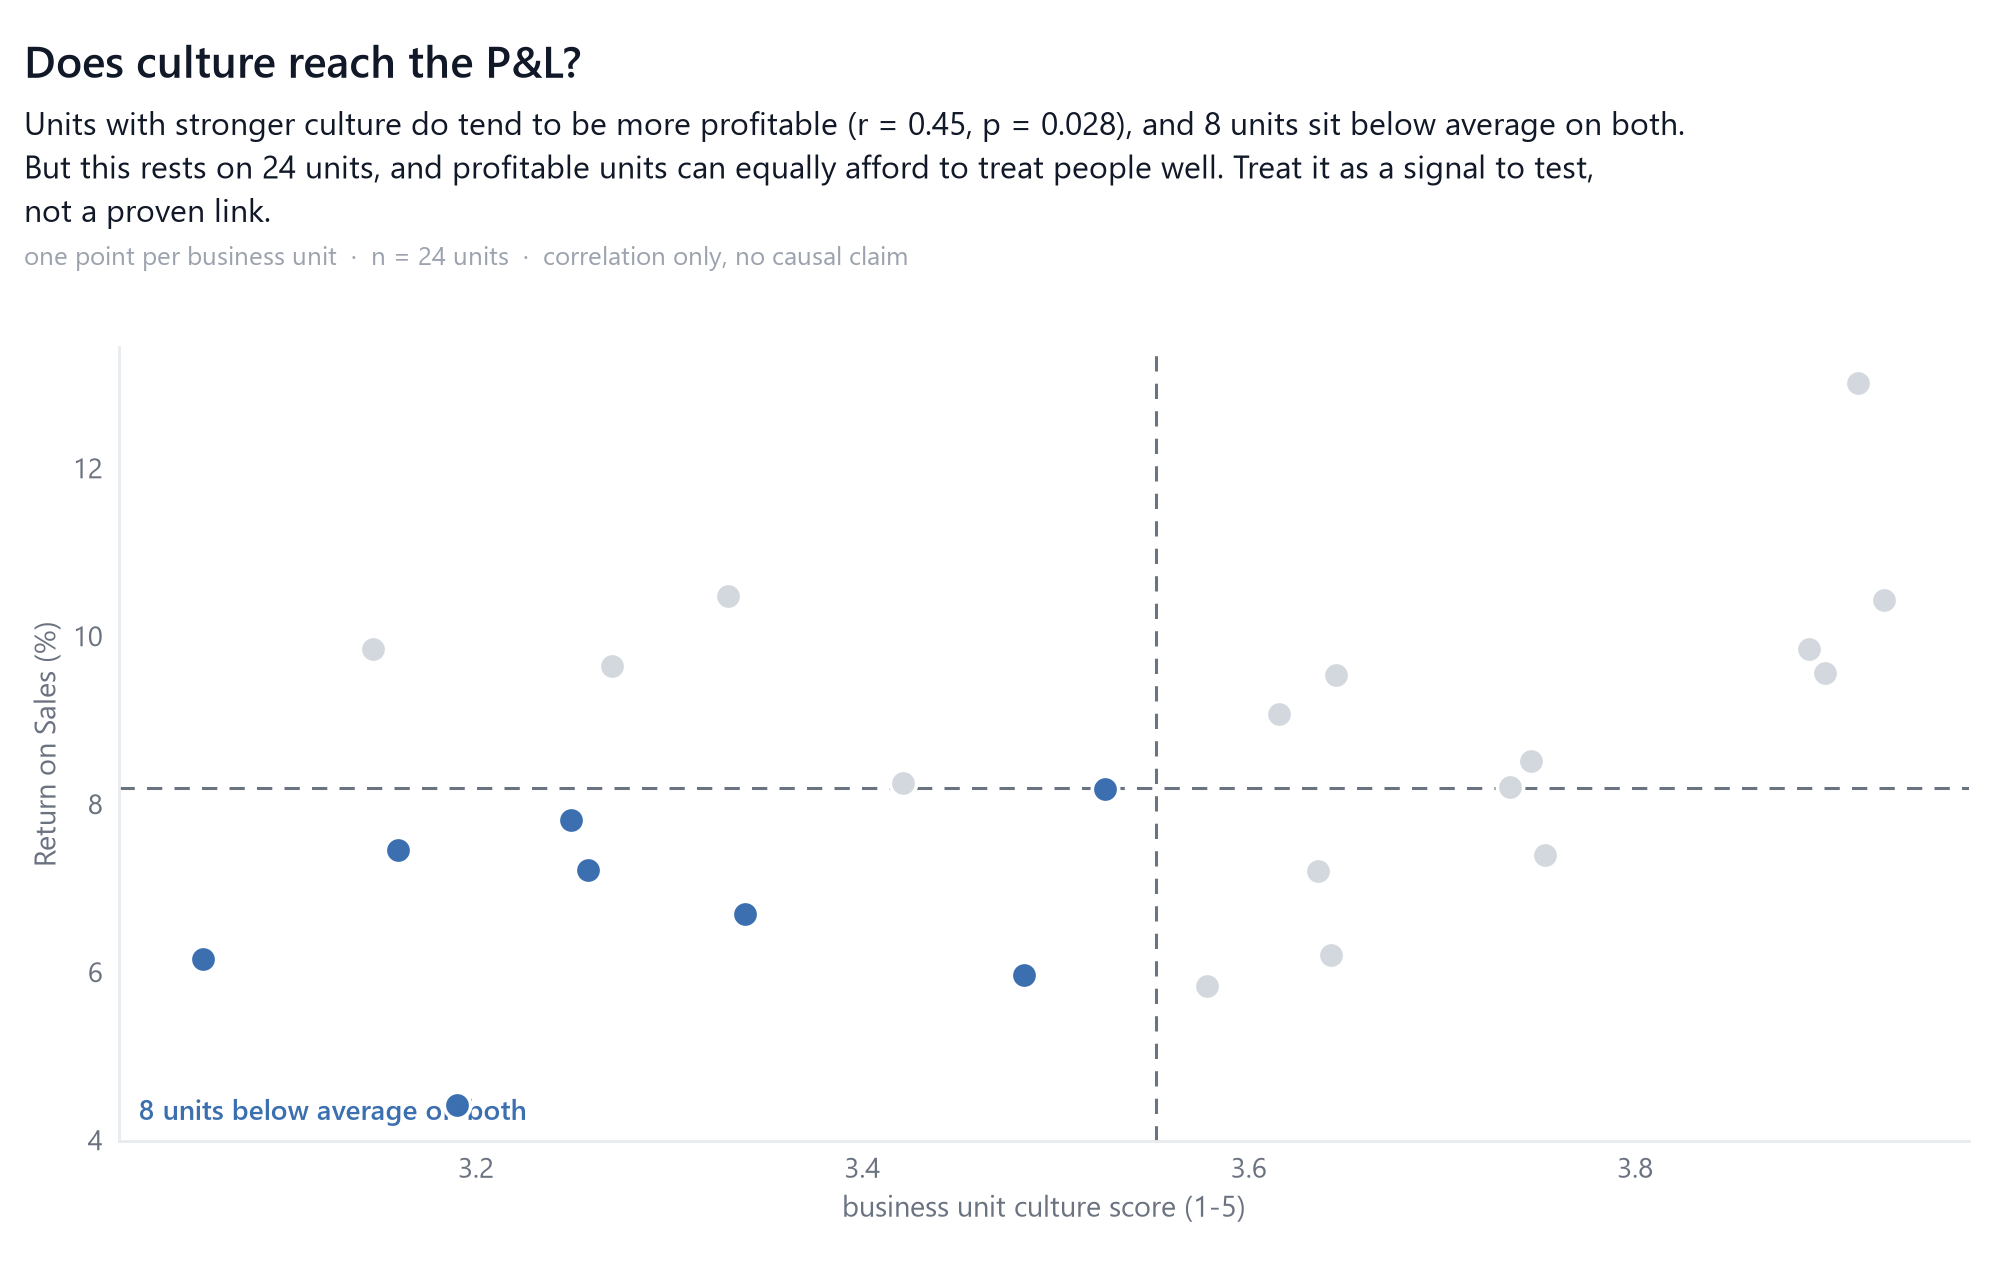

In [12]:
from scipy import stats

correlation, p_value = stats.pearsonr(unit_data["culture_index"],
                                      unit_data["return_on_sales_pct"])
leave_one_out = pd.read_csv(config.RESULTS_DIR / "05_leave_one_out.csv")
icc = pd.read_csv(config.RESULTS_DIR / "05_icc_table.csv")

print(f"culture vs Return on Sales: r = {correlation:.3f}, p = {p_value:.3f}, "
      f"n = {len(unit_data)} units")
print(f"ICC(2) = {icc['icc2'].min():.2f} -> unit averages are reliable enough to compare")
print()
print("leave-one-out check:")
print(f"  r ranges {leave_one_out['r_without_unit'].min():.3f} to "
      f"{leave_one_out['r_without_unit'].max():.3f} depending which unit is dropped")
print(f"  still significant in {int(leave_one_out['still_significant'].sum())} "
      f"of {len(leave_one_out)} versions")

draw(figures.plot_culture_vs_profit, unit_data)

**What this says.** Units with stronger culture do tend to be more
profitable (r = 0.45, p = 0.03), and 8 of the 24 units sit below average on both.
The direction matches the published literature.

**What it does not say, and this is most of the story:**

- **The sample is 24.** Not 4,850 — 24. The 95% confidence interval on that
  correlation runs from **0.055 to 0.721**, which is compatible with "barely
  anything" and "quite strong" at the same time.
- **It is not robust.** Dropping any single one of 4 units takes the result below
  significance, and the correlation moves between 0.35 and 0.53 depending on
  which unit is left out.
- **Ecological fallacy.** This is a relationship between unit *averages*. It
  licenses no statement about individual employees — the within-unit
  relationship could be zero.
- **Reverse causality is just as plausible.** Profitable units can afford better
  staffing, equipment and training. Nothing here separates that from culture
  driving profit.

My conclusion is that this is a hypothesis worth testing properly with several
survey waves and culture measured *before* the profit period — not a result.

## 11. What I found

**On the measurement**

- All eight culture scales are internally reliable (alpha 0.850 to 0.893). One
  weak question was removed.
- But they are **not eight distinct things**. Credibility and leadership are
  statistically inseparable (r = 0.76), one general "halo" factor sits under
  everything, and an eighth factor turned out to be an artefact of how the
  reverse-worded questions are phrased.

**On what drives satisfaction**

- The eight topics plus demographics explain **47% of the differences between
  individuals** in satisfaction.
- **Leadership, fairness and pride** form the top tier. Camaraderie and wellbeing
  matter least once the others are accounted for.
- The exact order within the top tier is not settled — the topics overlap so much
  that the best of them uniquely explains only 1.2% of the variance.

**On where the problem is**

- Demographic differences are **small**. The largest effect anywhere explains
  3.2% of the variation in a topic.
- The one worth acting on is **Chennai's wellbeing**, 0.27 points below the
  company average, with leadership 0.15 below.
- **21% of employees are at risk**, and five of the 24 units hold a third of them.

**On the business link**

- Weak leadership ratings identify at-risk employees very sharply: **73% versus
  4%**.
- Unit culture correlates with Return on Sales at 0.45, but on 24 units this is
  a signal to test, not a proven link.

**If I had to give one recommendation:** target leadership and fairness in the
five worst units. That is where the largest effect meets the weakest scores meets
the highest concentration of at-risk people.

## 12. What I would not claim

Four weaknesses, in the order I think they matter. I would rather state these
than be caught by them.

**1. Common method bias.** The predictors and the outcome come from the same
person, on the same form, at the same moment. Someone in a bad mood marks
everything down, which manufactures correlation out of nothing. The evidence is
in my own data: a first eigenvalue of 23.85 against a second of 2.19 is what a
strong shared response tendency looks like. **R² = 0.474 should be read as an
upper bound, not an estimate.** Fixing it needs an outcome from a different
source — actual turnover records, absence data, manager ratings.

**2. No causal identification.** Cross-sectional, observational, one wave. Every
result is an association. A credible causal design would need culture measured
before the outcome period, several waves, and unit fixed effects.

**3. Clustering is ignored.** Employees are nested inside 24 business units and
ICC(1) = 0.11, so their answers are not independent — which is exactly what the
regression's standard errors assume. My effective sample is smaller than 4,846,
so the confidence intervals are somewhat too narrow. A mixed-effects model with
random intercepts by unit would fix it. This is a genuine omission and the first
thing I would add.

**4. The eight topics are not eight topics.** Reliability is fine; discriminant
validity is not. Reporting a ranked table of eight drivers implies a separation
the measurement does not support.

*(Also: missing data is assumed to be missing at random, which I did not test.
If people skipped the wellbeing questions because they felt burnt out, wellbeing
scores are biased upward and nothing here would reveal it.)*

---

**Reproducing this**

```
pip install -r requirements.txt
python run_all.py --regenerate
python -m pytest tests -q
```

The whole pipeline runs in about 8 seconds and is deterministic. 23 tests cover
the pieces that would silently corrupt everything downstream if they were wrong
— reverse-coding, the alpha calculation, and the scoring logic — with expected
values worked out by hand rather than copied from a library.